# 01 — Data Profiling & Exploratory Data Analysis
Cleaning summary, class balance, descriptive statistics, distributions, and the **data profile sent to the LLMs**. Outputs are written to `results/01_profiling.xlsx` and `results/*.png`.

In [1]:
import json, inspect, warnings, os, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler, QuantileTransformer)
from sklearn.metrics import (accuracy_score, matthews_corrcoef, roc_auc_score, recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy import stats
from lightgbm import LGBMClassifier
os.makedirs("results", exist_ok=True)
RS = 42
TEAL,ROSE,ORANGE,SAND,RED,LAV,SLATE,INK = ('#4A90A4','#C4887D','#E67E22','#C4A882','#C0392B','#8E7CC3','#7A8B9A','#2C3E4F')
plt.rcParams.update({'font.family':'DejaVu Sans','axes.facecolor':'#FAFBFC','figure.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.color':'#E4E9F0',
    'axes.titleweight':'bold','axes.axisbelow':True,'savefig.dpi':200,'savefig.bbox':'tight'})
NAMES = ['Manual Expert','DeepSeek','Claude Sonnet 4.6','GPT-5.4','CAAFE']
SHORT = ['Manual','DeepSeek','Claude 4.6','GPT-5.4','CAAFE']
COLS  = [TEAL,ROSE,RED,ORANGE,LAV]
CONT  = ['AGE','ANNUALCONTRIBUTION','ANNUALCLAIMAMOUNT','UNITSTOTAL']
DATA  = "Final Prepared Dataset - Diabetes and Hypertension Data.xlsx"

def load_raw():
    df = pd.read_excel(DATA)
    n_raw = len(df); df = df.drop_duplicates().reset_index(drop=True); n_dup = n_raw - len(df)
    df["ADHERENCE"] = (df["ADHERENCE"]=="ADHERENT").astype(int)
    for c in df.columns:
        if df[c].dtype=="bool": df[c]=df[c].astype(int)
    return df, n_raw, n_dup

def load_and_split():
    df,_,_ = load_raw()
    y=df["ADHERENCE"]; X=df.drop(columns=["ADHERENCE"])
    return train_test_split(X,y,test_size=0.2,stratify=y,random_state=RS)

def _manual(Xp):
    Xp=Xp.copy()
    Xp["LOG_CLAIM"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]); Xp["LOG_UNITS"]=np.log1p(Xp["UNITSTOTAL"])
    Xp["LOG_CONTRIB"]=np.log1p(Xp["ANNUALCONTRIBUTION"])
    Xp["CLAIM_PER_UNIT"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["UNITSTOTAL"]+1))
    Xp["CLAIM_RATIO"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["ANNUALCONTRIBUTION"]+1))
    Xp["UNITS_PER_AGE"]=Xp["UNITSTOTAL"]/(Xp["AGE"]+1); return Xp

_NS={"np":np,"pd":pd,"StandardScaler":StandardScaler,"RobustScaler":RobustScaler,
     "PowerTransformer":PowerTransformer,"MinMaxScaler":MinMaxScaler,"QuantileTransformer":QuantileTransformer}
def _load(p):
    ns=dict(_NS); exec(open(p,encoding="utf-8").read(),ns); return ns["preprocess"]
FROZEN={"DeepSeek":_load("llm_raw/DeepSeek_preprocess.py"),
        "Claude Sonnet 4.6":_load("llm_raw/Claude_Sonnet_4.6_preprocess.py"),
        "GPT-5.4":_load("llm_raw/GPT-5.4_preprocess.py")}
def _caafe(frame):
    ns={"df":frame.copy(),"np":np,"pd":pd}; exec(open("llm_raw/CAAFE_code.py",encoding="utf-8").read(),ns)
    return ns["df"].select_dtypes(include=[np.number]).fillna(0)
def transform_pair(name,x_fit,x_eval):
    if name=="Manual Expert": return _manual(x_fit),_manual(x_eval)
    if name=="CAAFE":
        tr=_caafe(x_fit); te=_caafe(x_eval).reindex(columns=tr.columns,fill_value=0); return tr,te
    tr,te=FROZEN[name](x_fit.copy(),x_eval.copy())
    if not isinstance(tr,pd.DataFrame):
        cols=(list(x_fit.columns)+["CONTRIBUTION_CLAIM_RATIO","UNITS_PER_CLAIM"]) if (name=="DeepSeek" and tr.shape[1]==x_fit.shape[1]+2) else [f"f{i}" for i in range(tr.shape[1])]
        tr=pd.DataFrame(tr,index=x_fit.index,columns=cols)
    if not isinstance(te,pd.DataFrame): te=pd.DataFrame(te,index=x_eval.index,columns=tr.columns)
    return tr,te.reindex(columns=tr.columns,fill_value=0)
def san(df): return pd.DataFrame(df).replace([np.inf,-np.inf],np.nan).fillna(0.0)
def nb_se(d,k=10):
    d=np.asarray(d); n=d.size; return np.sqrt(d.var(ddof=1)*(1.0/n+(1.0/k)/(1-1.0/k)))
def tost90(d,k=10):
    d=np.asarray(d); m=d.mean(); se=nb_se(d,k); c=stats.t.ppf(0.95,d.size-1); return m,se,[m-c*se,m+c*se]
def cv_metrics(name,X,y,drop_units=False,k=10,repeats=1):
    accs,mccs,aucs=[],[],[]
    for r in range(repeats):
        for tr,va in StratifiedKFold(k,shuffle=True,random_state=(RS if repeats==1 else 2026+r)).split(X,y):
            ftr,fva=transform_pair(name,X.iloc[tr],X.iloc[va])
            if drop_units:
                uc=[c for c in ftr.columns if 'UNIT' in c.upper()]
                ftr=ftr.drop(columns=uc); fva=fva.drop(columns=[c for c in uc if c in fva.columns])
            ftr,fva=san(ftr),san(fva)
            m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(ftr,y.iloc[tr])
            p=m.predict(fva); pr=m.predict_proba(fva)[:,1]
            accs.append(accuracy_score(y.iloc[va],p)); mccs.append(matthews_corrcoef(y.iloc[va],p)); aucs.append(roc_auc_score(y.iloc[va],pr))
    return np.array(accs),np.array(mccs),np.array(aucs)
x_tr,x_ho,y_tr,y_ho = load_and_split()
print("Setup complete |", f"{len(x_tr)+len(x_ho):,} records, {x_tr.shape[1]} predictors")

Setup complete | 24,071 records, 11 predictors


### Cleaning & class balance

Raw rows 24,084; duplicates removed 13; analysis rows 24,071


,Partition,N,Adherent,Adherent %
0,Overall,24071,9669,40.2
1,Training,19256,7735,40.2
2,Holdout,4815,1934,40.2


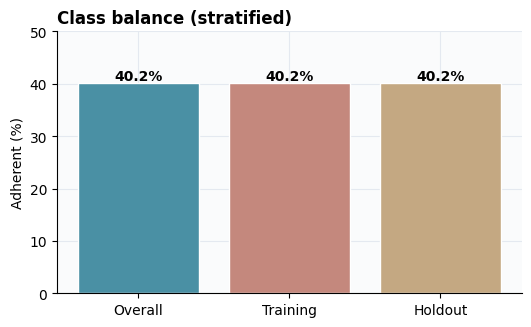

In [2]:
df,n_raw,n_dup=load_raw()
bal=pd.DataFrame({'Partition':['Overall','Training','Holdout'],
 'N':[len(df),len(x_tr),len(x_ho)],
 'Adherent':[int(df.ADHERENCE.sum()),int(y_tr.sum()),int(y_ho.sum())],
 'Adherent %':[round(df.ADHERENCE.mean()*100,1),round(y_tr.mean()*100,1),round(y_ho.mean()*100,1)]})
print(f"Raw rows {n_raw:,}; duplicates removed {n_dup}; analysis rows {len(df):,}")
display(bal)
fig,ax=plt.subplots(figsize=(6,3.4)); ax.bar(bal.Partition,bal['Adherent %'],color=[TEAL,ROSE,SAND],edgecolor='white')
for i,v in enumerate(bal['Adherent %']): ax.text(i,v+0.5,f'{v}%',ha='center',fontweight='bold')
ax.set_ylabel('Adherent (%)'); ax.set_ylim(0,50); ax.set_title('Class balance (stratified)',loc='left')
plt.savefig('results/01_class_balance.png'); plt.show()

### Descriptive statistics of continuous predictors

In [3]:
rows=[]
for c in CONT:
    s=x_tr[c]; q1,q3=s.quantile(.25),s.quantile(.75); iqr=q3-q1
    out=int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum())
    rows.append([c,round(s.median(),1),f"[{q1:.0f}, {q3:.0f}]",f"{s.min():.0f}-{s.max():.0f}",round(s.skew(),1),out,int(s.isna().sum())])
desc=pd.DataFrame(rows,columns=['Feature','Median','IQR','Range','Skew','Outliers(1.5IQR)','Missing'])
display(desc)

,Feature,Median,IQR,Range,Skew,Outliers(1.5IQR),Missing
0,AGE,56.0,"[46, 66]",16-103,0.2,12,0
1,ANNUALCONTRIBUTION,6889900.0,"[2718696, 6889900]",211764-11770788,-0.7,0,0
2,ANNUALCLAIMAMOUNT,40291.1,"[12299, 102120]",1-1299691096,111.2,1959,0
3,UNITSTOTAL,336.0,"[120, 720]",1-12847800,99.2,1243,0


### Distributions (log scale) and correlation with the target

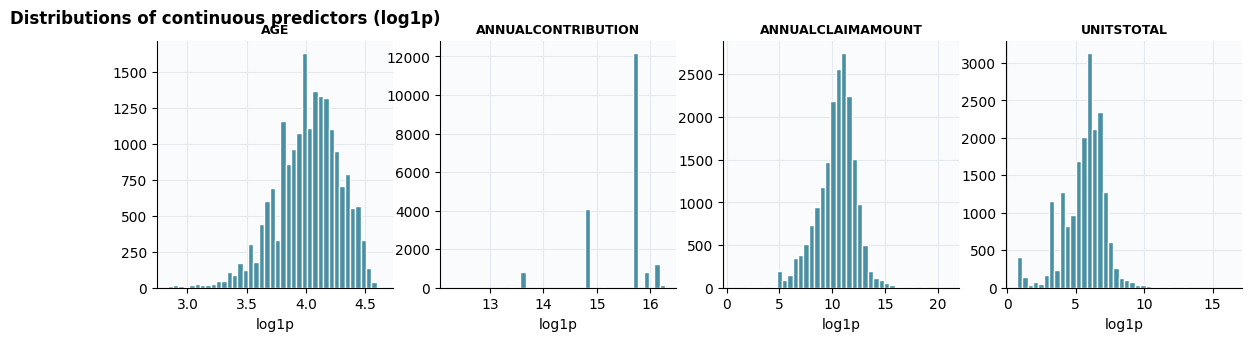

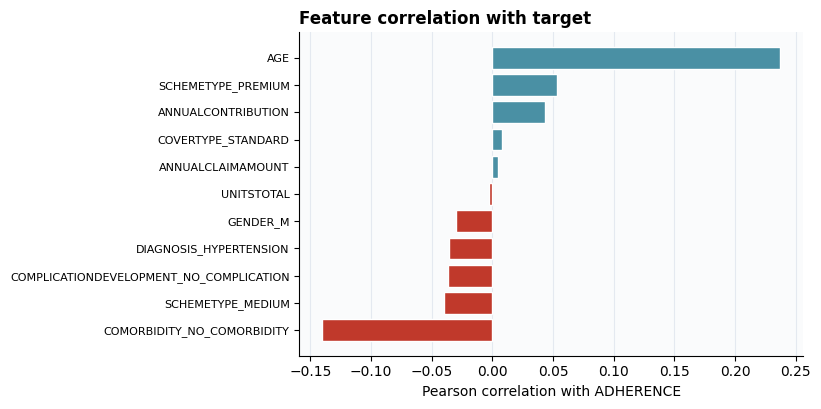

In [4]:
fig,axs=plt.subplots(1,4,figsize=(14,3.2))
for ax,c in zip(axs,CONT):
    ax.hist(np.log1p(x_tr[c]),bins=40,color=TEAL,edgecolor='white'); ax.set_title(c,fontsize=9); ax.set_xlabel('log1p')
plt.suptitle('Distributions of continuous predictors (log1p)',x=0.02,ha='left',fontweight='bold')
plt.savefig('results/01_distributions.png'); plt.show()
corr=x_tr.apply(lambda col: np.corrcoef(col,y_tr)[0,1]).sort_values()
fig,ax=plt.subplots(figsize=(6.5,4.2)); ax.barh(range(len(corr)),corr.values,color=[RED if v<0 else TEAL for v in corr.values],edgecolor='white')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index,fontsize=8); ax.set_xlabel('Pearson correlation with ADHERENCE')
ax.set_title('Feature correlation with target',loc='left'); ax.grid(axis='y',alpha=0)
plt.savefig('results/01_target_corr.png'); plt.show()
corr_df=corr.reset_index(); corr_df.columns=['Feature','Corr_with_target']

### Data profile supplied to the LLMs (Stage 1)

In [5]:
def build_profile(x, y, include_target=True):
    L=[f"Dataset: {len(x)} rows, {x.shape[1]} features. Binary target, {y.mean():.1%} positive.",
       f"Features: {list(x.columns)}","Per-continuous-feature statistics:"]
    for c in CONT:
        s=x[c]; q1,q3=s.quantile(.25),s.quantile(.75); iqr=q3-q1
        o=int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum())
        line=f"  {c}: dtype={s.dtype}, missing=0, unique={s.nunique()}, skew={s.skew():.2f}, IQR=[{q1:.1f},{q3:.1f}], outliers={o}"
        if include_target: line+=f", target_corr={np.corrcoef(s,y)[0,1]:+.4f}"
        L.append(line)
    L.append("7 binary features, 4 continuous. No missing values."); return "\n".join(L)
profile=build_profile(x_tr,y_tr); print(profile)
open('results/01_llm_data_profile.txt','w').write(profile)
with pd.ExcelWriter('results/01_profiling.xlsx') as w:
    bal.to_excel(w,'class_balance',index=False); desc.to_excel(w,'descriptive',index=False); corr_df.to_excel(w,'target_corr',index=False)
print('Saved results/01_profiling.xlsx')

Dataset: 19256 rows, 11 features. Binary target, 40.2% positive.
Features: ['AGE', 'ANNUALCONTRIBUTION', 'ANNUALCLAIMAMOUNT', 'UNITSTOTAL', 'GENDER_M', 'SCHEMETYPE_MEDIUM', 'SCHEMETYPE_PREMIUM', 'DIAGNOSIS_HYPERTENSION', 'COVERTYPE_STANDARD', 'COMORBIDITY_NO_COMORBIDITY', 'COMPLICATIONDEVELOPMENT_NO_COMPLICATION']
Per-continuous-feature statistics:
  AGE: dtype=int64, missing=0, unique=86, skew=0.15, IQR=[46.0,66.0], outliers=12, target_corr=+0.2372
  ANNUALCONTRIBUTION: dtype=float64, missing=0, unique=10, skew=-0.68, IQR=[2718696.0,6889900.0], outliers=0, target_corr=+0.0437
  ANNUALCLAIMAMOUNT: dtype=float64, missing=0, unique=18030, skew=111.25, IQR=[12298.9,102120.3], outliers=1959, target_corr=+0.0051
  UNITSTOTAL: dtype=float64, missing=0, unique=1786, skew=99.20, IQR=[120.0,720.0], outliers=1243, target_corr=-0.0025
7 binary features, 4 continuous. No missing values.


Saved results/01_profiling.xlsx
